In [45]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [46]:
urls = [
    'https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html',
    'https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html',
    'https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html',
    'https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html',
    'https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html',
    # --- NEW URLs ---
    'https://techncruncher.blogspot.com/2022/03/sellfy-review-2022-how-good-is-this.html',
    'https://techncruncher.blogspot.com/2022/03/prowritingaid-vs-grammarly-which.html',
    'https://techncruncher.blogspot.com/2025/12/how-i-get-free-traffic-from-chatgpt-in.html',
    'https://techncruncher.blogspot.com/2022/04/what-is-blockchain-everything-you-need.html',
    'https://techncruncher.blogspot.com/2022/06/most-frequently-asked-questions-about.html'    
]

In [49]:
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
articles = []

for url in urls:
    try:
        # Fetch the page content
        res = requests.get(url, headers=headers, timeout=10)
        res.raise_for_status()
        soup = BeautifulSoup(res.content, 'lxml')

        # Extract Title
        title = soup.find('h3', class_='post-title')
        title = title.get_text(strip=True) if title else soup.title.get_text(strip=True)

        # Extract Body Text
        content_div = soup.find('div', class_='post-body entry-content')
        if not content_div:
            print(f"[SKIP] No content block found: {url}")
            continue

        paragraphs = content_div.find_all('p')
        text = ' '.join(p.get_text(strip=True) for p in paragraphs)

        # Skip short articles for quality control
        if len(text) > 100:
            articles.append({'url': url, 'title': title, 'text': text})
        else:
            print(f"[SKIP] Too short: {url}")

        time.sleep(1)   # Be polite to the server
    except Exception as e:
        print(f"[ERROR] {url} -> {e}")

df = pd.DataFrame(articles)
print(f"\nScraped {len(df)} of {len(urls)} articles.")
df.head()

[SKIP] Too short: https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html

Scraped 9 of 10 articles.


,url,title,text
0,https://techncruncher.blogspot.com/2025/01/top...,Top 10 AI Tools That Will Transform Your Conte...,Looking to level up your content creation gam...
1,https://techncruncher.blogspot.com/2023/12/lim...,"LimeWire AI Studio Review 2023: Details, Prici...",In the rapidly advancing landscape of AI tech...
2,https://techncruncher.blogspot.com/2023/01/top...,Top 10 AI Tools in 2023 That Will Make Your Li...,"In this article, we explore the top 10 AI too..."
3,https://techncruncher.blogspot.com/2022/11/top...,Top 10 AI Content Generator & Writer Tools in ...,There are a number of different AI content ...
4,https://techncruncher.blogspot.com/2022/03/sel...,Sellfy Review 2022: How Good Is This Ecommerce...,Are you searching for an ecomerce platform to...


In [50]:
df.to_csv("articles_raw.csv", index=False)
print("Successfully saved articles_raw.csv with" , len(df), "articles.")


Successfully saved articles_raw.csv with 9 articles.


In [61]:
import spacy
import pandas as pd

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# --- THE FUNCTION MUST BE DEFINED HERE ---
def extract_features(text):
    """Process text with spaCy and extract linguistic features."""
    doc = nlp(str(text)) 
    sentences = list(doc.sents)
    
    return pd.Series({
        'num_tokens':          len(doc),
        'num_sentences':       len(sentences),
        'num_entities':        len(doc.ents),
        'num_nouns':           len([t for t in doc if t.pos_ == 'NOUN']),
        'num_verbs':           len([t for t in doc if t.pos_ == 'VERB']), 
        'avg_sentence_length': (len(doc) / len(sentences)) if sentences else 0.0
    })


if not df.empty:
    # Drop old columns to fix the duplicate issue from earlier
    df = df.drop(columns=['num_tokens', 'num_sentences', 'num_entities', 'num_nouns', 'num_verbs', 'avg_sentence_length'], errors='ignore')
    
    # Now we call the function
    features = df['text'].apply(extract_features)
    df = pd.concat([df, features], axis=1)
    df['title_length'] = df['title'].apply(len)

    print("Features extracted successfully (including verbs and avg sentence length).")
    
    display(df[['title', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns', 'num_verbs', 'avg_sentence_length']].head())
else:
    print("No articles found for feature extraction.")

Features extracted successfully (including verbs and avg sentence length).


,title,num_tokens,num_sentences,num_entities,num_nouns,num_verbs,avg_sentence_length
0,Top 10 AI Tools That Will Transform Your Conte...,1188.0,47.0,24.0,321.0,150.0,25.276596
1,"LimeWire AI Studio Review 2023: Details, Prici...",1723.0,65.0,103.0,420.0,200.0,26.507692
2,Top 10 AI Tools in 2023 That Will Make Your Li...,1480.0,52.0,39.0,331.0,166.0,28.461538
3,Top 10 AI Content Generator & Writer Tools in ...,1319.0,63.0,89.0,271.0,140.0,20.936508
4,Sellfy Review 2022: How Good Is This Ecommerce...,1072.0,50.0,39.0,245.0,151.0,21.440000


In [62]:
doc = nlp(df['text'].iloc[0][:1500])

print("First 15 named entities in article 1:\n")
for ent in list(doc.ents)[:15]:
    print(f"  {ent.text:<35} {ent.label_:<12} ({spacy.explain(ent.label_)})")

First 15 named entities in article 1:

  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  10                                  CARDINAL     (Numerals that do not fall under another type)
  AI                                  GPE          (Countries, cities, states)
  2025                                DATE         (Absolute or relative dates or periods)
  AI                                  GPE          (Countries, cities, states)
  Dive Into the Top 10                WORK_OF_ART  (Titles of books, songs, etc.)
  2025                                DATE         (Absolute or relative dates or periods)
  Magic Studio                        PERSON       (People, including fictional)
  AI                                  ORG          (Companies, agencies, institutions, etc.)


In [63]:
from textblob import TextBlob

def get_sentiment(text):
    """Polarity in [-1, 1]; subjectivity in [0, 1]."""
    blob = TextBlob(text)
    return pd.Series({
        'sentiment_polarity':     blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity
    })

if not df.empty:
    sentiment_features = df['text'].apply(get_sentiment)
    df = pd.concat([df, sentiment_features], axis=1)

    print("Sentiment features extracted successfully.\n")
    display(df[['title', 'sentiment_polarity', 'sentiment_subjectivity']])

Sentiment features extracted successfully.



,title,sentiment_polarity,sentiment_subjectivity
0,Top 10 AI Tools That Will Transform Your Conte...,0.229493,0.583603
1,"LimeWire AI Studio Review 2023: Details, Prici...",0.219387,0.573587
2,Top 10 AI Tools in 2023 That Will Make Your Li...,0.197417,0.436441
3,Top 10 AI Content Generator & Writer Tools in ...,0.214853,0.564907
4,Sellfy Review 2022: How Good Is This Ecommerce...,0.167458,0.400369
5,ProWritingAid VS Grammarly: Which Grammar Chec...,0.314474,0.572368
6,How I Get Free Traffic from ChatGPT in 2025 (A...,0.142988,0.450002
7,What is Blockchain: Everything You Need to Kno...,0.119076,0.433248
8,Most Frequently Asked Questions About Affiliat...,0.159591,0.420867


In [65]:
# Persist the fully engineered table -- this is the Lab 02 deliverable.
df.to_csv("articles.csv", index=False)
print("Saved articles.csv with", df.shape[1], "columns:")
print(list(df.columns))

Saved articles.csv with 12 columns:
['url', 'title', 'text', 'title_length', 'num_tokens', 'num_sentences', 'num_entities', 'num_nouns', 'num_verbs', 'avg_sentence_length', 'sentiment_polarity', 'sentiment_subjectivity']


GRAPHS 

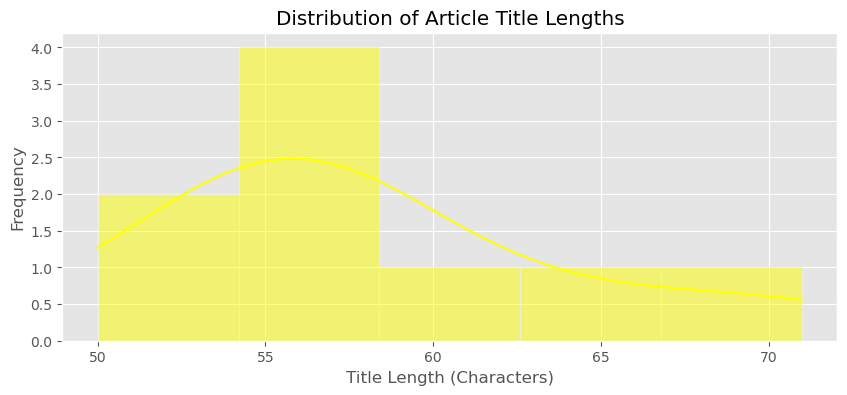

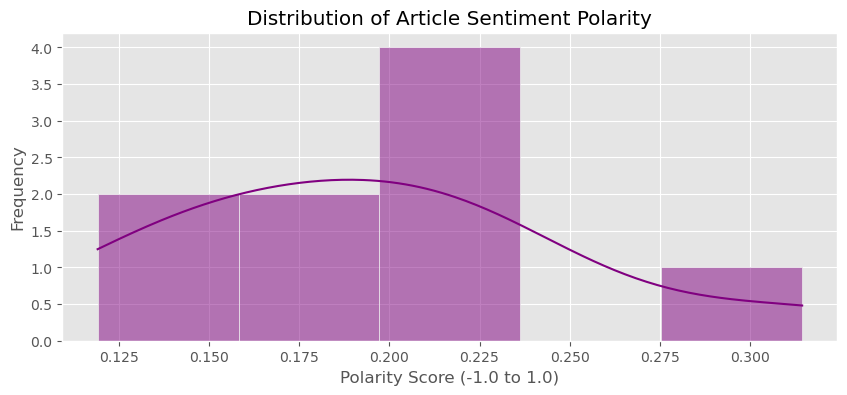

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# 1. Title Length Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['title_length'], kde=True, bins=5, color='yellow')
plt.title('Distribution of Article Title Lengths')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Frequency')
plt.show()

# 2. Sentiment Polarity Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['sentiment_polarity'], kde=True, bins=5, color='purple')
plt.title('Distribution of Article Sentiment Polarity')
plt.xlabel('Polarity Score (-1.0 to 1.0)')
plt.ylabel('Frequency')
plt.show()

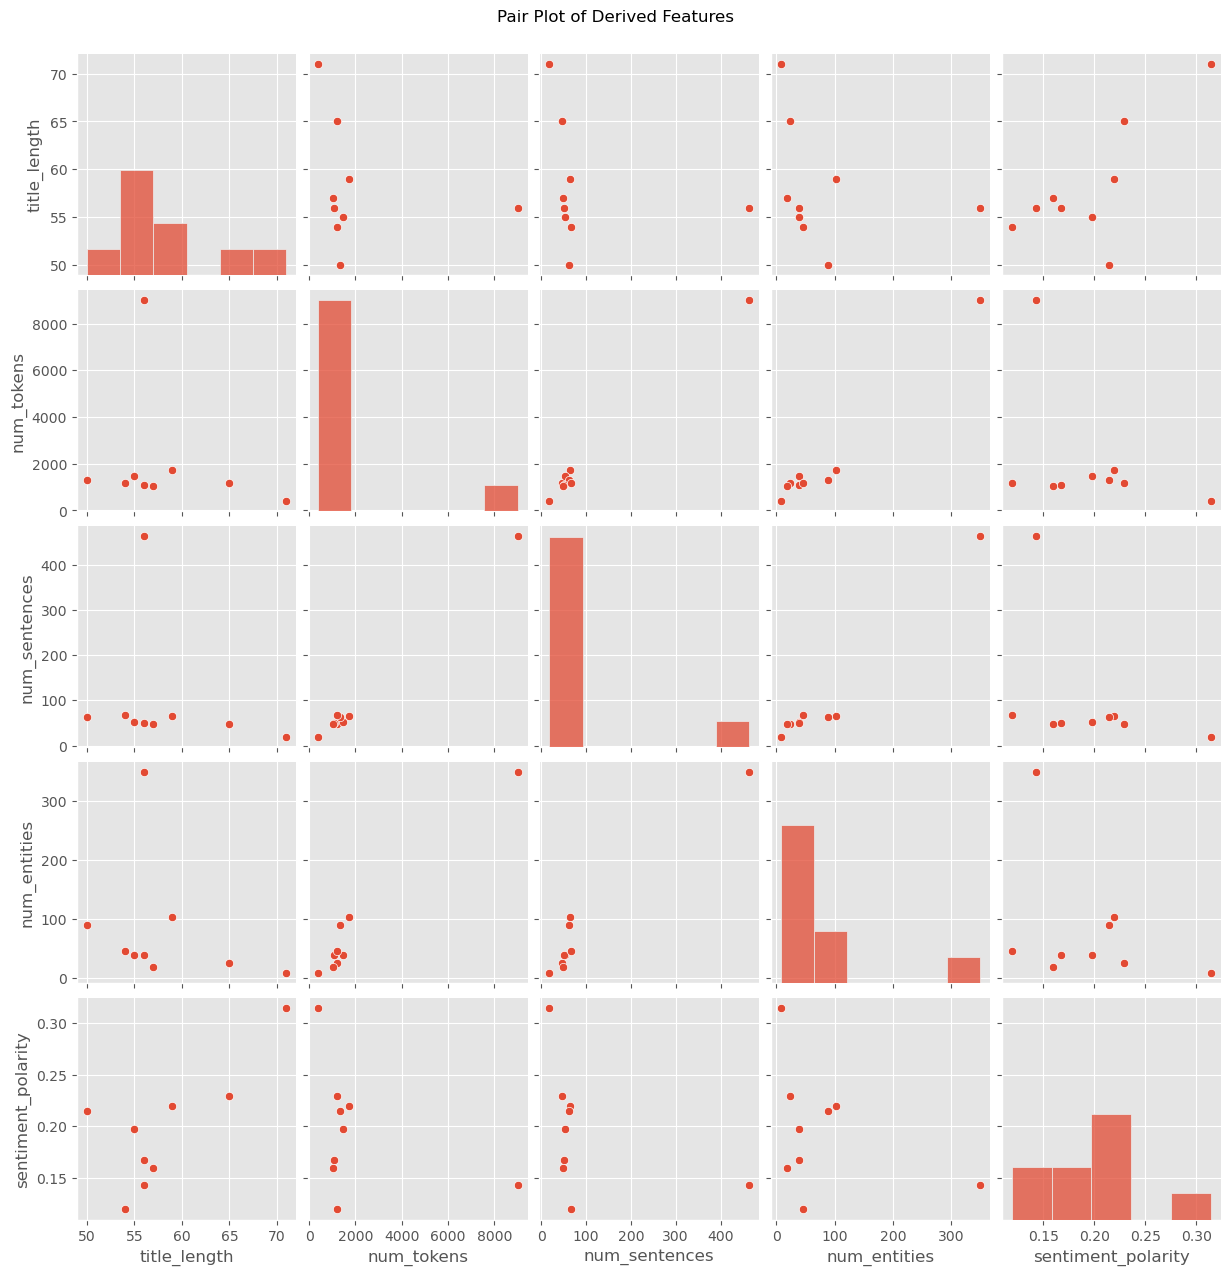

In [68]:
numeric_cols = [
    'title_length',
    'num_tokens',
    'num_sentences',
    'num_entities',
    'sentiment_polarity'
]

sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot of Derived Features', y=1.02)
plt.show()

In [69]:
# The same information as numbers.
print("Correlation matrix:\n")
display(df[numeric_cols].corr().round(2))

Correlation matrix:



,title_length,num_tokens,num_sentences,num_entities,sentiment_polarity
title_length,1.00,-0.21,-0.21,-0.28,0.74
num_tokens,-0.21,1.00,1.00,0.98,-0.40
num_sentences,-0.21,1.00,1.00,0.97,-0.41
num_entities,-0.28,0.98,0.97,1.00,-0.37
sentiment_polarity,0.74,-0.40,-0.41,-0.37,1.00


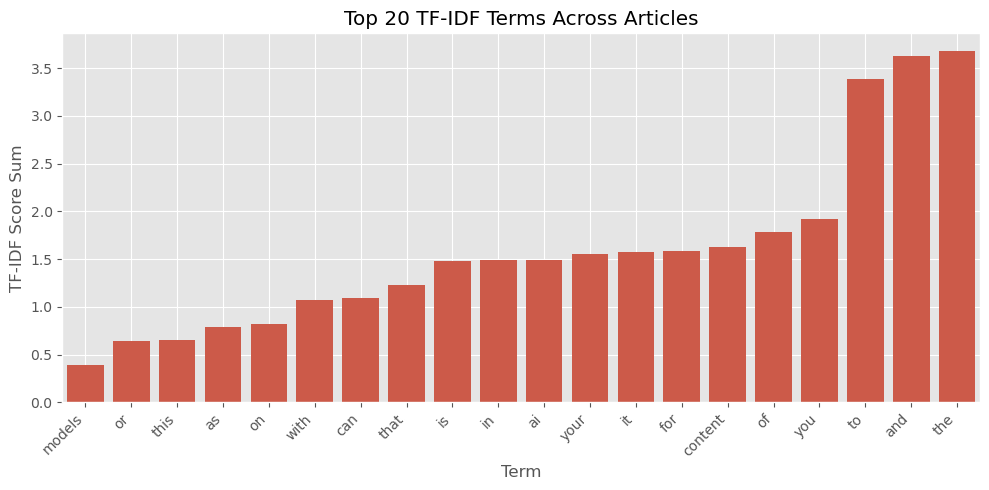

Sparse matrix shape (documents x terms): (9, 20)


In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

# stop_words='english' discards 'the', 'a', ...; max_features keeps the top 20
vectorizer = TfidfVectorizer(stop_words=None , max_features=20)

X = vectorizer.fit_transform(df['text'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Sum each term's score across all documents to rank global importance
tfidf_sums = tfidf_df.sum().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=tfidf_sums.index, y=tfidf_sums.values)
plt.title("Top 20 TF-IDF Terms Across Articles")
plt.ylabel("TF-IDF Score Sum")
plt.xlabel("Term")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Sparse matrix shape (documents x terms):", X.shape)

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# --- Exercise 4: TF-IDF with and without stop-word removal ---------------

# stop_words='english' discards 'the', 'a', ...; max_features keeps the top 20
vect_stop = TfidfVectorizer(stop_words='english', max_features=20)
vect_none = TfidfVectorizer(stop_words=None, max_features=20)

top_stop = (pd.DataFrame(vect_stop.fit_transform(df['text']).toarray(),
                         columns=vect_stop.get_feature_names_out())
              .sum().sort_values(ascending=False))
              
top_none = (pd.DataFrame(vect_none.fit_transform(df['text']).toarray(),
                         columns=vect_none.get_feature_names_out())
              .sum().sort_values(ascending=False))

comparison = pd.DataFrame({
    "with stop_words='english'": top_stop.index,
    "with stop_words=None":      top_none.index,
})
display(comparison)

print("\nTerms that appear ONLY when stop words are kept:")
print(sorted(set(top_none.index) - set(top_stop.index)))

,with stop_words='english',with stop_words=None
0,content,the
1,ai,and
2,creators,to
3,tool,you
4,plan,of
5,affiliate,content
6,features,for
7,platform,it
8,tools,your
9,blockchain,ai



Terms that appear ONLY when stop words are kept:
['and', 'as', 'can', 'for', 'in', 'is', 'it', 'of', 'on', 'or', 'that', 'the', 'this', 'to', 'with', 'you', 'your']
